In [25]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the JSON responses
with open('/home/ubuntu/Multimodal-Uncertainty-Quantification/llava_mmt_output1_uq_io.json', 'r') as file:
    responses_with_uncertainty = json.load(file)

# Load the DataFrame with correct answers
df = pd.read_csv('/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets/MMT-Bench/MMT-Bench_VAL.tsv', sep='\t')
df = df[df['category'].str.contains('hallucination')]

# # Extract the answers from the DataFrame
true_answers = dict(zip(range(2787,2866), df['answer']))






In [26]:
# true_answers

A
A
B
A
B
B
A
A
B
B
C
A
B
A
C
A
B
A
A
A


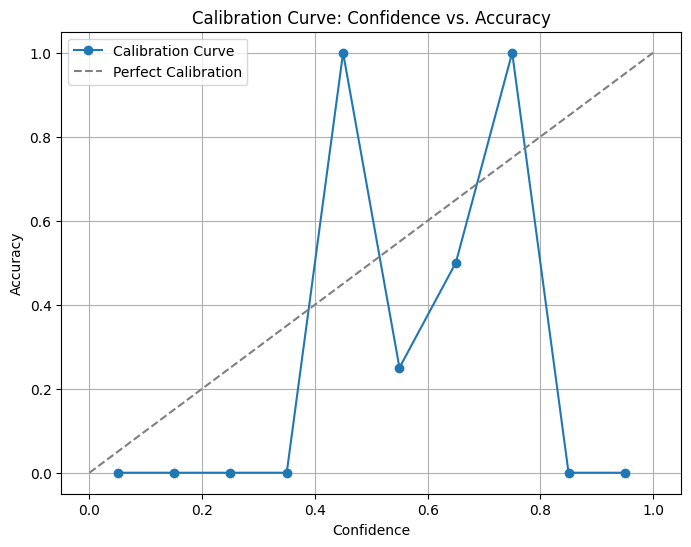

In [28]:
# import json
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # Load the JSON responses
# with open('/home/ubuntu/Multimodal-Uncertainty-Quantification/llava_mmt_output1_uq_io.json', 'r') as file:
#     responses_with_uncertainty = json.load(file)

# # Load the DataFrame with correct answers
# df = pd.read_csv('/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets/MMT-Bench/MMT-Bench_VAL.tsv', sep='\t')

# # Extract the answers from the DataFrame using the 'index' column as keys
# true_answers = dict(zip(df['index'].astype(str), df['answer']))

# Initialize lists to store uncertainties and accuracies
uncertainties = []
accuracies = []

# Extract data from responses_with_uncertainty
for idx, result in responses_with_uncertainty.items():
    responses = result['responses']
    uncertainty = result['uncertainty']
    true_answer = true_answers.get(int(idx))
    print(true_answer)
    # Calculate if the model's answer is correct
    correct = any(response['answer'] == true_answer for response in responses)
    
    # Append the data to lists
    uncertainties.append(uncertainty)
    accuracies.append(int(correct))

# Convert lists to NumPy arrays
uncertainties = np.nan_to_num(uncertainties, nan=1.0)  # Replace NaN values with 1.0
uncertainties = 1 - np.array(uncertainties)
accuracies = np.array(accuracies)

# Bin data by uncertainty
def bin_data(uncertainties, accuracies, num_bins=10):
    bins = np.linspace(0, 1, num_bins + 1)
    bin_indices = np.digitize(uncertainties, bins) - 1

    bin_centers = (bins[:-1] + bins[1:]) / 2  # Calculate bin centers for plotting
    bin_accuracies = []

    for i in range(num_bins):
        bin_mask = bin_indices == i
        if np.any(bin_mask):
            bin_accuracies.append(np.mean(accuracies[bin_mask]))
        else:
            bin_accuracies.append(0)  # If no data points fall in the bin, set accuracy to 0

    return bin_centers, bin_accuracies

# Plot the calibration curve
def plot_calibration_curve(uncertainties, accuracies, num_bins=10):
    bin_centers, bin_accuracies = bin_data(uncertainties, accuracies, num_bins)
    
    plt.figure(figsize=(8, 6))
    plt.plot(bin_centers, bin_accuracies, marker='o', label='Calibration Curve')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
    plt.xlabel('Confidence')
    plt.ylabel('Accuracy')
    plt.title('Calibration Curve: Confidence vs. Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot the calibration curve
plot_calibration_curve(uncertainties, accuracies, num_bins=10)


In [23]:
# replace nan with 1
uncertainties = np.nan_to_num(uncertainties, nan=1.0)

In [24]:
uncertainties

array([0.65126909, 0.6615563 , 0.68842387, 0.52782319, 0.70007793,
       0.60889476, 0.67786961, 0.56365429, 0.49228468, 0.65671015,
       0.62505953, 0.        , 0.58284668, 0.        , 0.61190248,
       0.58112841, 0.62053833, 0.6282588 , 0.69183434, 0.63443544])